In [39]:
## Import Libraries


import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Explainability
import shap

# Experiment Tracking
import mlflow
import mlflow.sklearn

# Save Model
import joblib

In [40]:
##Load data set

file_path = "C:/Users/shourya/Desktop/travel-mlops-project/data/flights.csv"


df = pd.read_csv(file_path)

print('=' * 60)
print('DATASET INFORMATION')
print('=' * 60) 

print(df.head())

print('\nDataset Shape:', df.shape)

DATASET INFORMATION
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops  09/26/2019  
1  1292.29  1.76    676.53  FlyingDrops  09/30/2019  
2  1487.52  1.66    637.56      CloudFy  10/03/2019  
3  1127.36  1.66    637.56      CloudFy  10/04/2019  
4  1684.05  2.16    830.86      CloudFy  10/10/2019  

Dataset Shape: (271888, 10)


In [6]:
print('\nDataset Info:')
print(df.info())

print('\nMissing Values:')
print(df.isnull().sum())

print('\nDescriptive Statistics:')
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB
None

Missing Values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Descriptive Statistics:
          travelCode       userCode         price           time  \
count  271888.00000

=== Descriptive Statistics ===


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000



Flight Type Counts:
flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64

Agency Counts:
agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


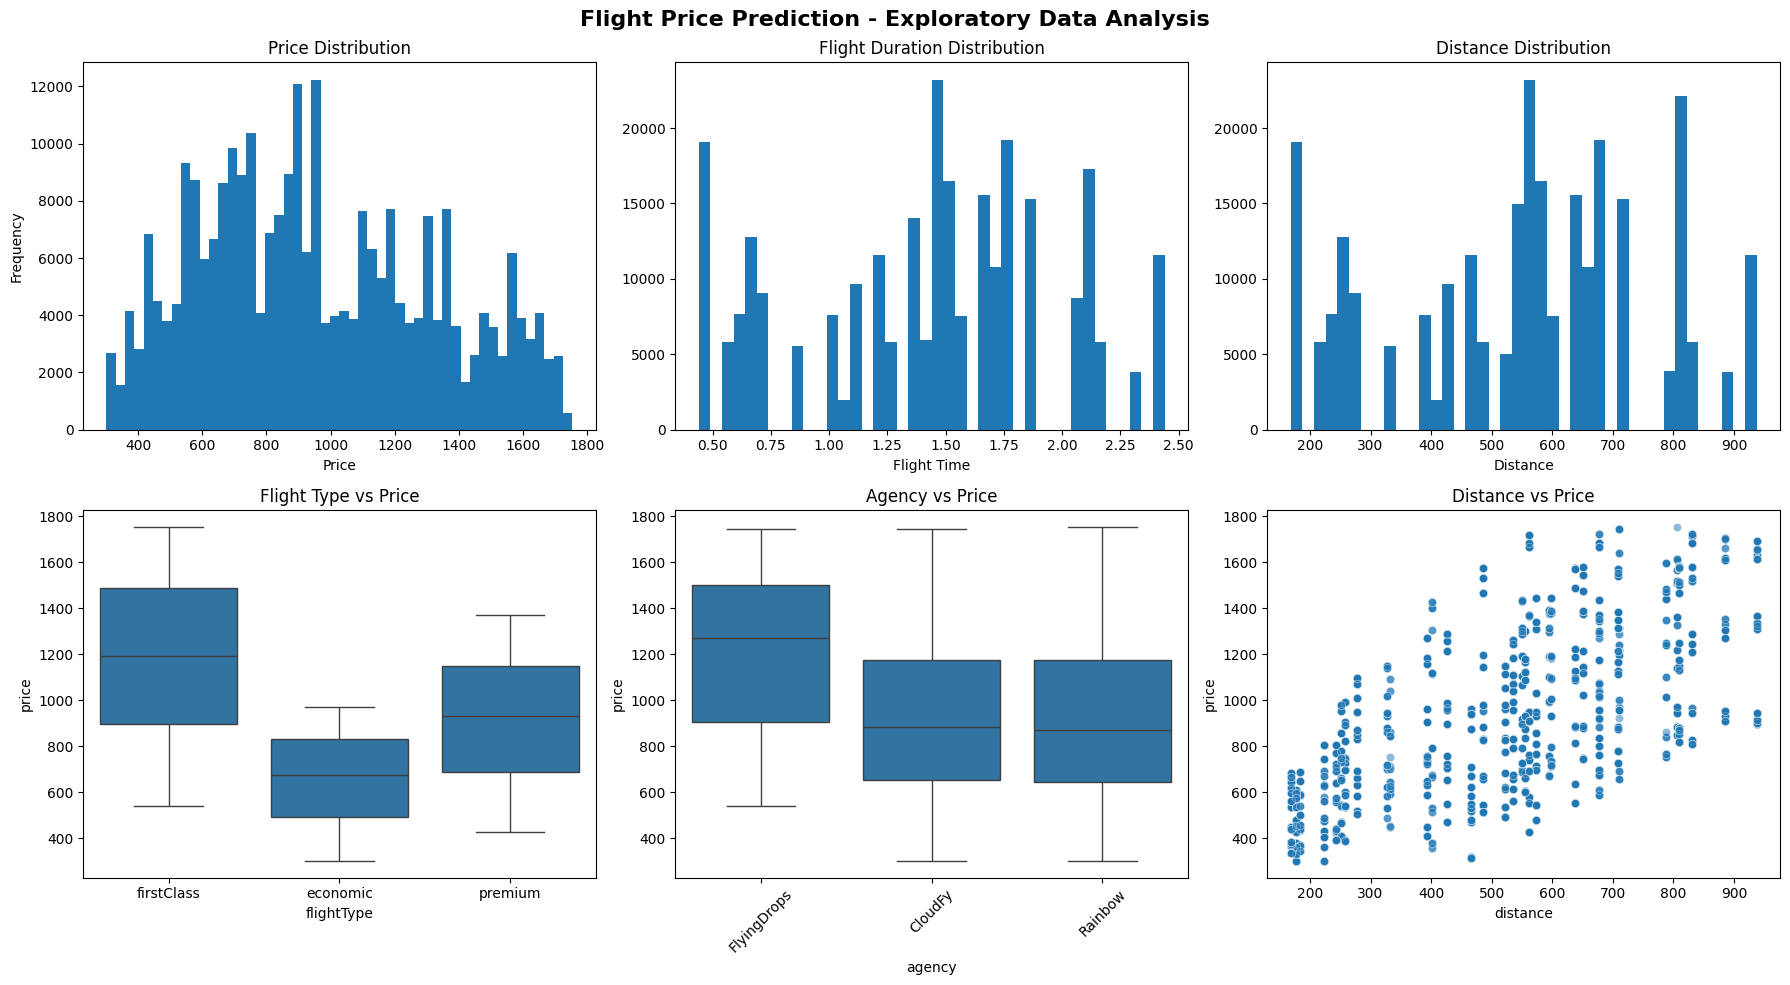

In [41]:
# =========================================================
# EXPLORATORY DATA ANALYSIS
# =========================================================

print('=== Descriptive Statistics ===')

display(df.describe())

print('\nFlight Type Counts:')

print(df['flightType'].value_counts())

print('\nAgency Counts:')

print(df['agency'].value_counts())

# =========================================================
# MAIN EDA VISUALS
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    'Flight Price Prediction - Exploratory Data Analysis',
    fontsize=16,
    fontweight='bold'
)

# Price Distribution
axes[0,0].hist(df['price'], bins=50)

axes[0,0].set_title('Price Distribution')

axes[0,0].set_xlabel('Price')

axes[0,0].set_ylabel('Frequency')

# Flight Time Distribution
axes[0,1].hist(df['time'], bins=40)

axes[0,1].set_title('Flight Duration Distribution')

axes[0,1].set_xlabel('Flight Time')

# Distance Distribution
axes[0,2].hist(df['distance'], bins=40)

axes[0,2].set_title('Distance Distribution')

axes[0,2].set_xlabel('Distance')

# Flight Type vs Price
sns.boxplot(
    data=df,
    x='flightType',
    y='price',
    ax=axes[1,0]
)

axes[1,0].set_title('Flight Type vs Price')

# Agency vs Price
sns.boxplot(
    data=df,
    x='agency',
    y='price',
    ax=axes[1,1]
)

axes[1,1].set_title('Agency vs Price')

axes[1,1].tick_params(axis='x', rotation=45)

# Distance vs Price
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x='distance',
    y='price',
    alpha=0.5,
    ax=axes[1,2]
)

axes[1,2].set_title('Distance vs Price')

plt.tight_layout()

plt.show()

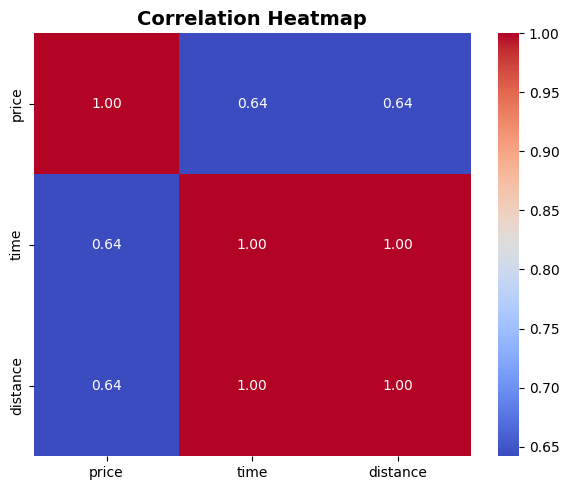

In [5]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

numeric_cols = [
    'price',
    'time',
    'distance'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Heatmap',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

In [42]:

print('\nPerforming Feature Engineering...')

# Convert Date

df['date'] = pd.to_datetime(df['date'])

# Date Features

df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

df['weekday'] = df['date'].dt.weekday

# Weekend Feature

df['is_weekend'] = df['weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

# Peak Month Feature

df['is_peak_month'] = df['month'].apply(
    lambda x: 1 if x in [6, 7, 12] else 0
)

# Duration Category

df['duration_category'] = pd.cut(
    df['time'],
    bins=[0, 2, 5, 10, 20],
    labels=['short', 'medium', 'long', 'very_long']
).astype(str)



Performing Feature Engineering...


In [43]:
# REMOVE LEAKAGE FEATURES

features = [

    'from',
    'to',
    'flightType',
    'time',
    'distance',
    'agency',
    'year',
    'month',
    'day',
    'weekday',
    'is_weekend',
    'is_peak_month',
    'duration_category'
]


target = 'price'

X = df[features]

y = df[target]

print('\nFinal Columns Used For Training:')
print(X.columns)



Final Columns Used For Training:
Index(['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year',
       'month', 'day', 'weekday', 'is_weekend', 'is_peak_month',
       'duration_category'],
      dtype='object')


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('\nTraining Shape:', X_train.shape)
print('Testing Shape:', X_test.shape)



Training Shape: (217510, 13)
Testing Shape: (54378, 13)


In [20]:
categorical_features = [

    'from',
    'to',
    'flightType',
    'agency',
    'duration_category'
]

numerical_features = [

    'time',
    'distance',
    'year',
    'month',
    'day',
    'weekday',
    'is_weekend',
    'is_peak_month'
]

# Numerical Transformer

numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())
])

# Categorical Transformer

categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combined Preprocessor

preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numerical_features),

        ('cat', categorical_transformer, categorical_features)
    ]
)


In [13]:
# =========================================================
# BASELINE LINEAR REGRESSION
# =========================================================

linear_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_predictions = linear_pipeline.predict(X_test)

linear_r2 = r2_score(y_test, linear_predictions)

print('\nLinear Regression R2:', linear_r2)



Linear Regression R2: 0.9192568027581374


In [14]:
rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestRegressor(random_state=42))
])

rf_params = {

    'model__n_estimators': [100, 200],

    'model__max_depth': [10, 15],

    'model__min_samples_split': [2, 5]
}

print('\nStarting Random Forest Hyperparameter Tuning...')

rf_grid = GridSearchCV(

    rf_pipeline,
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print('\nBest Random Forest Parameters:')
print(rf_grid.best_params_)



Starting Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Random Forest Parameters:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [15]:
xgb_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', XGBRegressor(random_state=42))
])

xgb_params = {

    'model__n_estimators': [100, 300],

    'model__max_depth': [5, 8],

    'model__learning_rate': [0.05, 0.1]
}

print('\nStarting XGBoost Hyperparameter Tuning...')

xgb_grid = GridSearchCV(

    xgb_pipeline,
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print('\nBest XGBoost Parameters:')
print(xgb_grid.best_params_)



Starting XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best XGBoost Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 300}


In [49]:
# =========================================================
# MODEL EVALUATION
# =========================================================

models = {

    'Random Forest': rf_grid.best_estimator_,

    'XGBoost': xgb_grid.best_estimator_
}

results = []

mlflow.set_experiment('Final Production Flight Price Prediction')

for model_name, model in models.items():

    print('\n' + '=' * 60)
    print(f'MODEL: {model_name}')
    print('=' * 60)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=2,
        scoring='r2'
    )

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2 Score: {r2:.4f}')

    results.append({

        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'CV R2 Mean': cv_scores.mean()
    })

    with mlflow.start_run(run_name=model_name):

        mlflow.log_metric('MAE', mae)
        mlflow.log_metric('RMSE', rmse)
        mlflow.log_metric('R2', r2)
        mlflow.log_metric('CV_R2', cv_scores.mean())

        mlflow.sklearn.log_model(
            model,
            artifact_path=model_name
        )


NameError: name 'rf_grid' is not defined

In [17]:
# =========================================================
# FINAL MODEL COMPARISON
# =========================================================

results_df = pd.DataFrame(results)

print('\nFINAL MODEL COMPARISON')

print(results_df)




FINAL MODEL COMPARISON
           Model       MAE        MSE      RMSE  R2 Score  CV R2 Mean
0  Random Forest  0.845656  13.248853  3.639897  0.999899    0.896636
1        XGBoost  0.015668   0.000509  0.022572  1.000000    0.950241


In [28]:
# =========================================================
# BEST MODEL SELECTION
# =========================================================

best_model_name = results_df.sort_values(
    by='R2 Score',
    ascending=False
).iloc[0]['Model']

best_model = models[best_model_name]

joblib.dump(
    best_model,
    r'C:\Users\shourya\Desktop\travel-mlops-project\models\final_flight_price_model.pkl'
)

print('\nBest Model Saved Successfully!')

print(f'Best Model: {best_model_name}')

NameError: name 'results_df' is not defined

In [29]:
import joblib

best_model = joblib.load(
    r'C:\Users\shourya\Desktop\travel-mlops-project\models\final_flight_price_model.pkl'
)

best_model_name = 'XGBoost'

In [26]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

df['weekday'] = df['date'].dt.weekday

# Weekend Feature
df['is_weekend'] = df['weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

# Peak Travel Months
df['is_peak_month'] = df['month'].apply(
    lambda x: 1 if x in [6, 7, 12] else 0
)

# Duration Categories
df['duration_category'] = pd.cut(
    df['time'],
    bins=[0, 2, 5, 10, 20],
    labels=['short', 'medium', 'long', 'very_long']
).astype(str)

print('Feature Engineering Completed!')

Feature Engineering Completed!



Generating Feature Importance Plot...


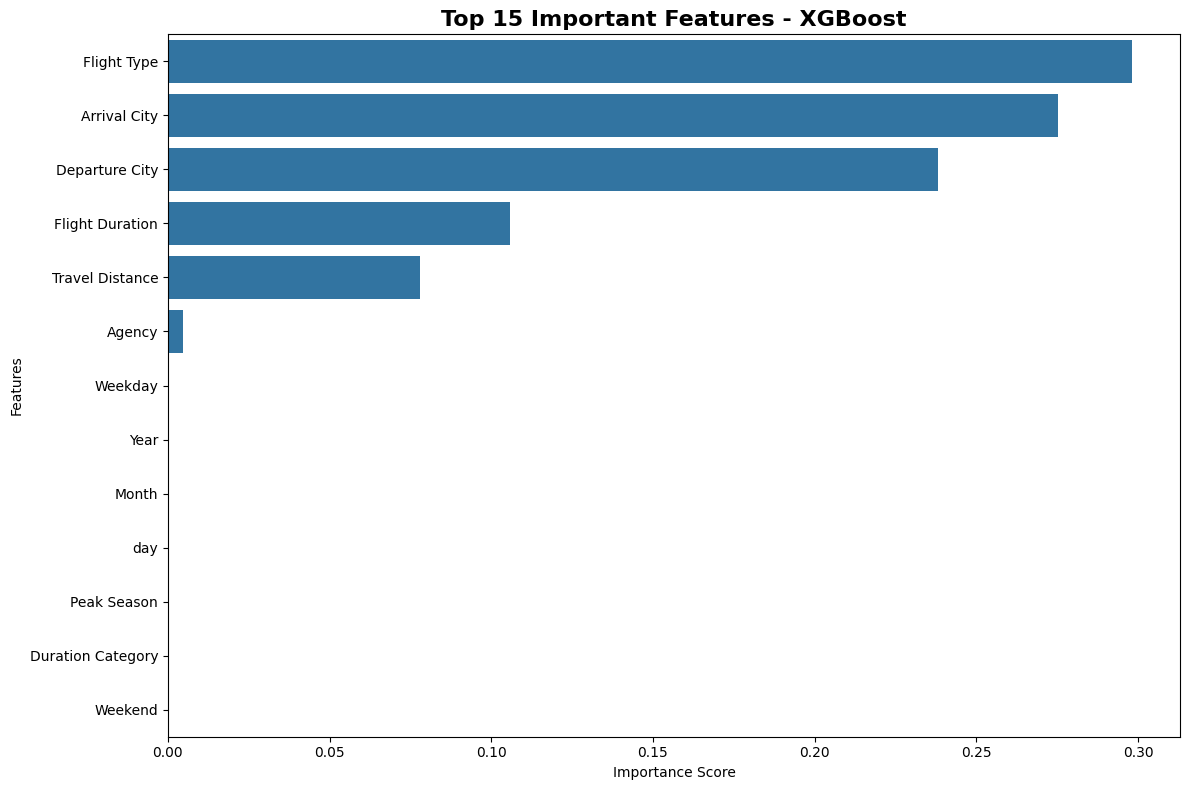

Feature Importance Visualization Generated Successfully!


In [27]:
## =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

print('\nGenerating Feature Importance Plot...')

# Extract Components
preprocessor_step = best_model.named_steps['preprocessor']

model_step = best_model.named_steps['model']

# Numerical Features
num_features = numerical_features

# Encoded Categorical Features
encoded_cat_features = preprocessor_step \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

# Combine Features
all_features = np.concatenate([
    num_features,
    encoded_cat_features
])

# Feature Importance DataFrame
feature_importance = pd.DataFrame({

    'Feature': all_features,

    'Importance': model_step.feature_importances_

})

# CLEAN FEATURE NAMES
# CLEAN FEATURE NAMES
# =========================================================
# GROUP FEATURES PROPERLY
# =========================================================

def group_feature(feature):

    if feature.startswith('from_'):
        return 'Departure City'

    elif feature.startswith('to_'):
        return 'Arrival City'

    elif feature.startswith('flightType_'):
        return 'Flight Type'

    elif feature.startswith('agency_'):
        return 'Agency'

    elif feature == 'time':
        return 'Flight Duration'

    elif feature == 'distance':
        return 'Travel Distance'

    elif feature == 'year':
        return 'Year'

    elif feature == 'month':
        return 'Month'

    elif feature == 'weekday':
        return 'Weekday'

    elif feature == 'is_weekend':
        return 'Weekend'

    elif feature == 'is_peak_month':
        return 'Peak Season'

    elif feature.startswith('duration_category'):
        return 'Duration Category'

    else:
        return feature

feature_importance['Feature'] = feature_importance['Feature'].apply(
    group_feature
)

# AGGREGATE IMPORTANCE
feature_importance = feature_importance.groupby(
    'Feature'
)['Importance'].sum().reset_index()

# Sort Top Features
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Important Features - XGBoost',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.tight_layout()

plt.show()

print('Feature Importance Visualization Generated Successfully!')

In [30]:
joblib.dump(
    best_model,
    r'C:\Users\shourya\Desktop\travel-mlops-project\models\final_flight_price_model.pkl'
)

['C:\\Users\\shourya\\Desktop\\travel-mlops-project\\models\\final_flight_price_model.pkl']

In [47]:
# =========================================================
# FINAL MLFLOW LOGGING
# =========================================================

import mlflow

import mlflow.sklearn

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions
final_predictions = best_model.predict(X_test)

# Metrics
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = final_mse ** 0.5

final_r2 = r2_score(
    y_test,
    final_predictions
)

# Set Experiment
mlflow.set_experiment(
    "Flight Price Prediction Final"
)

# Start Run
with mlflow.start_run():

    # Parameters
    mlflow.log_param(
        "Model",
        best_model_name
    )

    # Metrics
    mlflow.log_metric(
        "MAE",
        final_mae
    )

    mlflow.log_metric(
        "RMSE",
        final_rmse
    )

    mlflow.log_metric(
        "R2 Score",
        final_r2
    )

    # Model
    mlflow.sklearn.log_model(
        best_model,
        "flight_price_model"
    )

    print("MLflow Run Logged Successfully!")

2026/05/20 13:38:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/20 13:38:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow Run Logged Successfully!
